# Netflix Data Analysis Project
Data Analytics Internship Project.
## Phase 1: Data Setup and Loading
- Downloaded dataset from Kaggle.
- Imported libraries: Pandas, NumPy, Matplotlib, Seaborn.
- Loaded CSV file into a DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Dataset/netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Phase 2: Data Cleaning

In [2]:
# Filling missing values in critical columns
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

# Checking if any missing values remain
df.isnull().sum()

C:\Users\sanda\AppData\Local\Temp\ipykernel_3456\3147166235.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['director'].fillna('Unknown', inplace=True)
C:\Users\sanda\AppData\Local\Temp\ipykernel_3456\3147166235.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment usi

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Phase 3: Exploratory Data Analysis (EDA)

i. Content Composition

C:\Users\sanda\AppData\Local\Temp\ipykernel_3456\40672653.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='pastel')


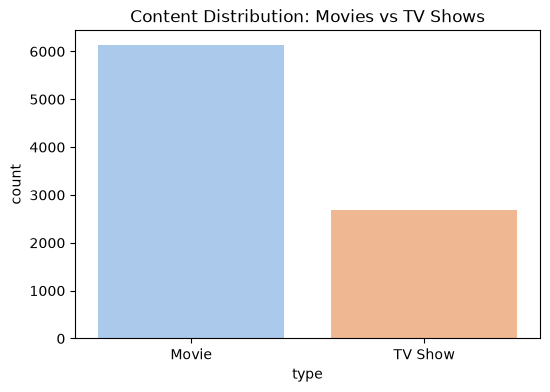

In [3]:
# Content Type Comparison
plt.figure(figsize=(6, 4))
sns.countplot(x='type', data=df, palette='pastel')
plt.title('Content Distribution: Movies vs TV Shows')
plt.show()

ii. Yearly Growth

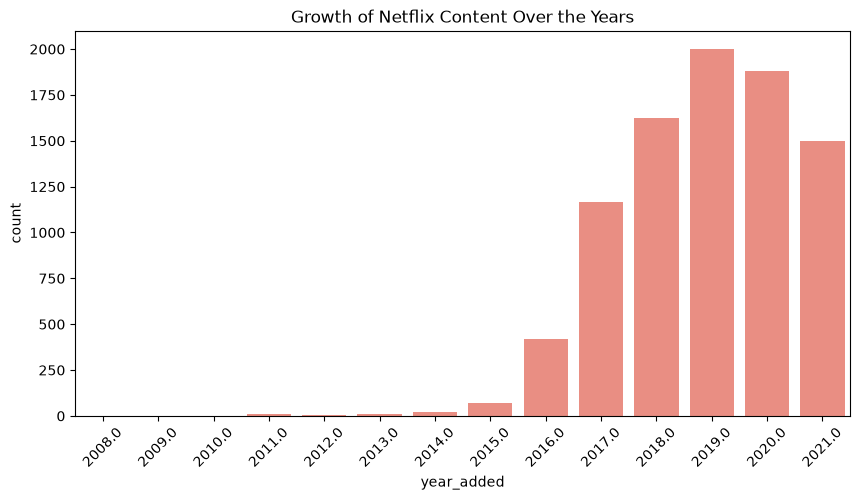

In [4]:
# Fixed code for Phase 3(ii)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'date_added' is in datetime format before plotting
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

# Plotting
plt.figure(figsize=(10, 5))
# Drop null years so they don't show up in the graph
sns.countplot(x=df['year_added'].dropna(), color='salmon')
plt.title('Growth of Netflix Content Over the Years')
plt.xticks(rotation=45)
plt.show()

iii. Top 5 Producing Countries

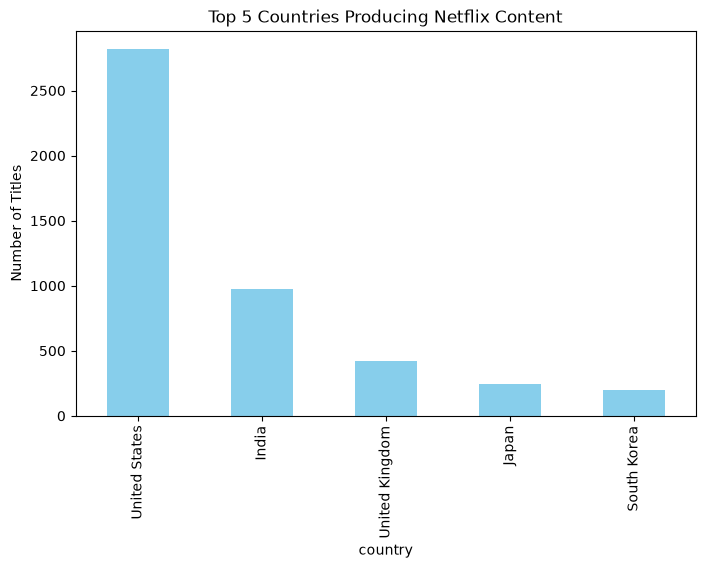

In [5]:
# Top 5 Countries Analysis
top_countries = df['country'].value_counts().head(5)
plt.figure(figsize=(8, 5))
top_countries.plot(kind='bar', color='skyblue')
plt.title('Top 5 Countries Producing Netflix Content')
plt.ylabel('Number of Titles')
plt.show()

## Phase 4: Feature Engineering

In [6]:
# Creating a new column 'duration_numeric' to extract numbers from duration
df['duration_numeric'] = df['duration'].str.extract('(\d+)')
df['duration_numeric'] = pd.to_numeric(df['duration_numeric'])

# Showing the first few rows to confirm the new column
df[['title', 'duration', 'duration_numeric']].head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\sanda\AppData\Local\Temp\ipykernel_3456\535782453.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['duration_numeric'] = df['duration'].str.extract('(\d+)')


,title,duration,duration_numeric
0,Dick Johnson Is Dead,90 min,90.0
1,Blood & Water,2 Seasons,2.0
2,Ganglands,1 Season,1.0
3,Jailbirds New Orleans,1 Season,1.0
4,Kota Factory,2 Seasons,2.0


## Phase 5: Visualization (Specific Insights)

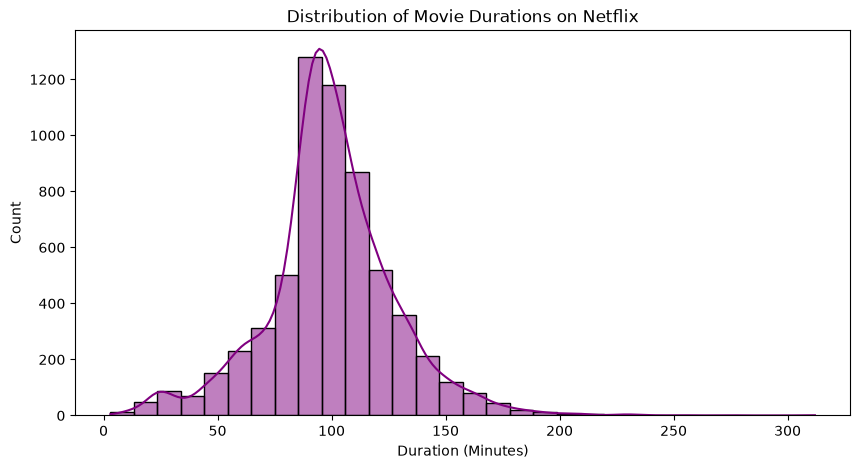

In [7]:
# Filtering data for Movies only
movies_df = df[df['type'] == 'Movie']

# Plotting the duration distribution
plt.figure(figsize=(10, 5))
sns.histplot(movies_df['duration_numeric'].dropna(), bins=30, kde=True, color='purple')
plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Duration (Minutes)')
plt.show()

## Phase 6: Business Insights

1. Content Strategy:
Netflix par Movies ka percentage TV Shows se zyada hai, jo indicate karta hai ki platform ka primary focus abhi bhi movies par hai.

2. Growth Trend:
Data se saaf pata chalta hai ki 2016 ke baad se Netflix ne content production mein tezi dikhayi hai, jo unke aggressive global expansion ka proof hai.

3. Target Audience:
'TV-MA' (Mature Audience) rating sabse zyada dominate kar rahi hai, iska matlab hai ki Netflix ka main target audience adults aur youngsters hain.

4. Regional Focus:
USA aur India top content producing countries hain. India mein Netflix ki heavy investment dikhati hai ki Indian market unke liye bahut important hai.

## Phase 7: Power BI Dashboard

1.Data Export:

In [8]:
df.to_csv('netflix_final_data.csv', index=False)